# **Boosting**

## **Introdução: Ensemble**

Ao construir uma árvore de decisão para resolver determinado problema, o algoritmo pode identificar padrões não lineares nos dados e criar regras simples que capturam as relações entre as variáveis, permitindo previsões mais precisas.

Porém, embora as árvores de decisão sejam uma ferramenta interressante, elas também apresentam alguma limitações.

Uma delas é o excesso de variância para árvores grandes (propensão ao *overfitting*), que ocorre quando o modelo se ajusta tão bem aos dados de treino, mas não consegue generalizar para dados não antes vistos.

Para superar as limitações das árvores de decisão individuais, podemos utilizar uma abordagem conhecida como ensemble, onde a ideia central é combinar vários modelos para obter um desempenho melhor do que qualquer um dos modelos individuais.

## **Entendendo Boosting**

*Boosting* é uma tipo de método *ensemble* que combina uma série de modelos simples para criar um modelo forte e robusto.

Ao invés de treinar todos os modelos de uma vez, o boosting treina os modelos de forma sequencial. Isso significa que cada novo modelo tenta corrigir os erros cometidos pelos modelos anteriores.

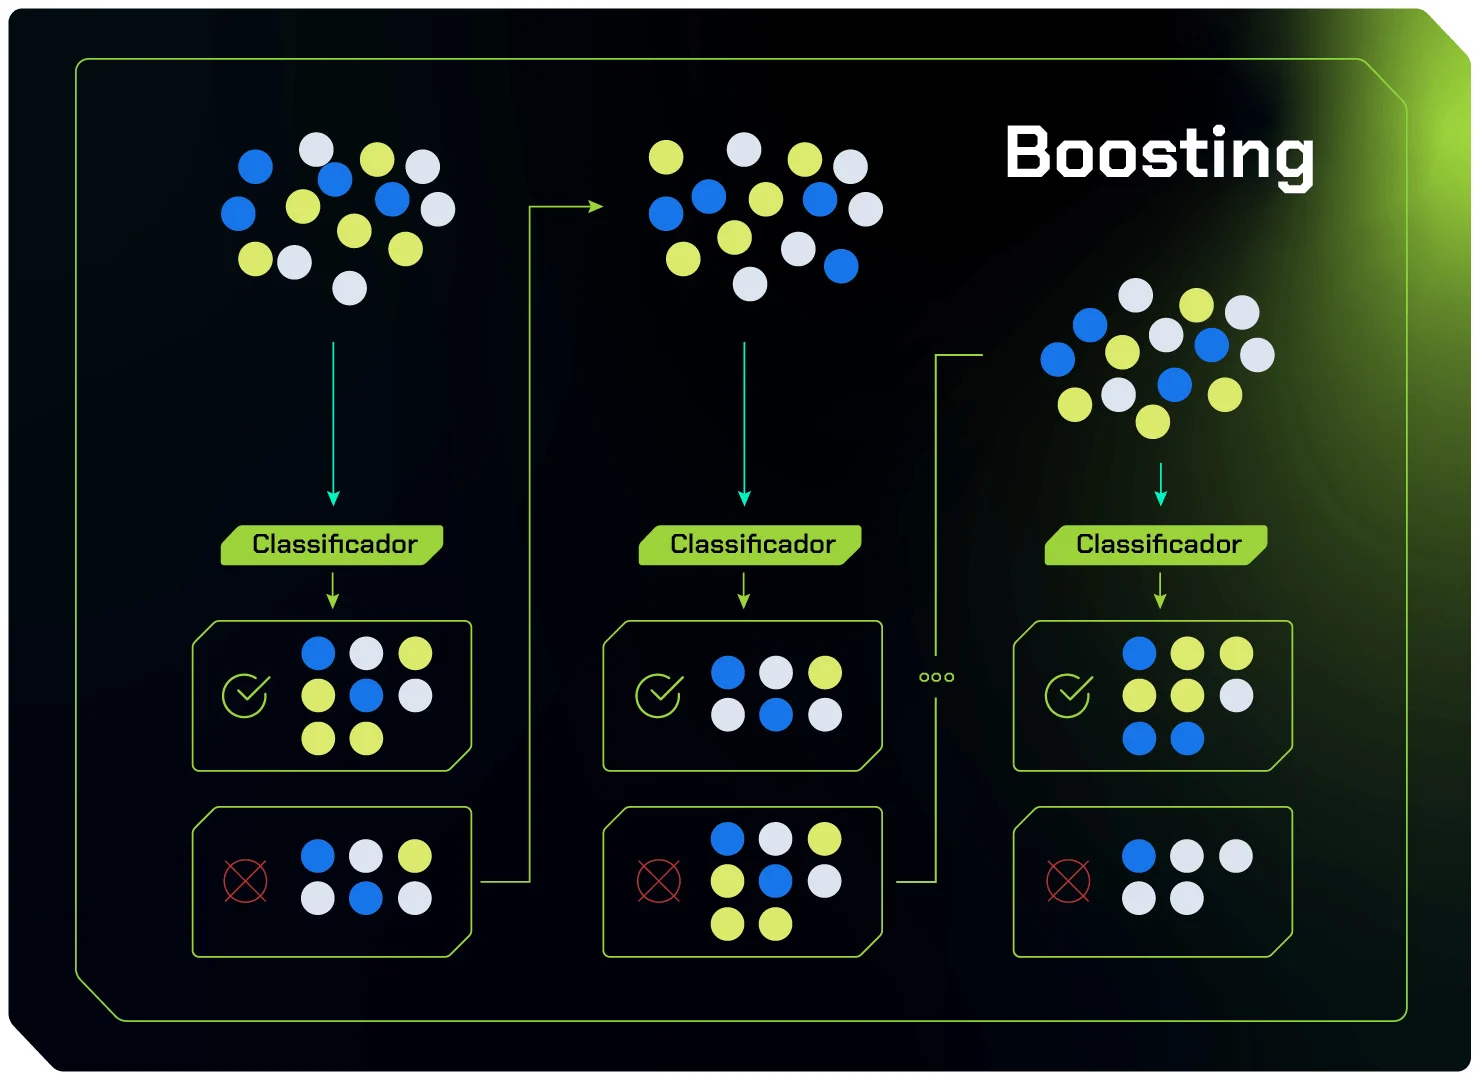

## **Algoritmos de Boosting**

1. `Adaptative Boosting ou AdaBoost`: É o algoritmo de boosting mais simples e, por isso, um excelente ponto de partida. Ele funciona de forma iterativa, ajustando o peso de cada exemplo no conjunto de treinamento a cada rodada. **Exemplos mais difíceis recebem mais peso, forçando o modelo a focar neles e melhorar sua precisão.**

2. `Gradient Boosting`: Possui um algoritmo de otimização para encontrar a direção que mais melhora o modelo a cada iteração. Essa abordagem garante que o modelo aprenda os erros de forma mais eficiente, levando a um desempenho superior em diversos problemas.

3. `XGboost`:É um dos algoritmos de boosting mais populares e poderosos. Ele combina a técnica de Gradient Boosting com várias otimizações, como regularização L1 e L2 e aprendizado em paralelo, o que resulta em um modelo extremamente rápido, preciso e robusto.

## **Implementação de Boosting**

In [1]:
# Importando bibliotecas:

import numpy as np

# Modelos de Ensemble do tipo Boosting
from xgboost.sklearn import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

# Train test split
from sklearn.model_selection import train_test_split

# Árvore de decisão
from sklearn.tree import DecisionTreeClassifier

# Dataset
from sklearn.datasets import load_digits

# Metricas de Avaliação
from sklearn.metrics import accuracy_score, classification_report

### Carregando o dataset

In [2]:
X, y = load_digits(return_X_y=True)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (1797, 64)
y shape: (1797,)


### Dados de treino e dados de teste

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (1168, 64)
X_test shape: (629, 64)
y_train shape: (1168,)
y_test shape: (629,)


### Instânciação dos modelos

In [4]:
model_decison_tree = DecisionTreeClassifier(max_depth=10)

In [5]:
ada_model = AdaBoostClassifier(estimator = model_decison_tree, random_state=42, learning_rate=0.1, n_estimators=100)

gradient_model = GradientBoostingClassifier(learning_rate=0.1, n_estimators=100, random_state=42, max_depth=10)

xgboost_model = XGBClassifier(n_estimators = 100, learning_rate = 0.1, max_depth = 10, random_state=42)

#### Treinamento, Avaliação e Predição dos modelos

In [6]:
models = {'AdaBoostClassifier': ada_model, 'GradientBoostingClassifier': gradient_model, 'XGBClassifier': xgboost_model}

In [7]:
def scores_models(models, X_train, y_train, X_test, y_test, metric):

    scores = {}

    for name_model,model in models.items():

        model.fit(X_train, y_train)

        predict_ = model.predict(X_test)

        score_model = metric(y_test, predict_)

        scores[name_model] = score_model

    return scores

In [8]:
scores = scores_models(models, X_train, y_train, X_test, y_test, accuracy_score)

In [9]:
for model, score in scores.items():

    print(f'Model: {model} | Accuracy score: {score:.2%}')

Model: AdaBoostClassifier | Accuracy score: 95.07%
Model: GradientBoostingClassifier | Accuracy score: 91.10%
Model: XGBClassifier | Accuracy score: 96.18%


In [10]:
# Resultado da árvore de decisão isolada:

model_decison_tree.fit(X_train, y_train)

predict_ = model_decison_tree.predict(X_test)

print(f'Model: Decision Tree | Accuracy score: {accuracy_score(y_test, predict_):.2%}')

Model: Decision Tree | Accuracy score: 84.58%


## **Referências**

- https://www.alura.com.br/artigos/metodo-boosting?srsltid=AfmBOopmF0ls94MrfKAS6cVinSUKWWgS84oBiy7voBv2kIUDCY4Vct5k